# Z24 Standard Time-Series Classification with tsai

**Author:** TRAN VAN PHUONG

This notebook converts the cleaned Z24 PDT data to the official tsai input contract and trains a PyTorch time-series classifier. It uses the same recording-level train, validation, and test isolation as the TensorFlow experiment.


## Time-series data contract

The tsai repository defines a three-dimensional input array with shape:

**samples x variables x sequence length**

For this experiment:

- one sample is one 80-second window;
- variables are the five common sensor channels;
- sequence length is 8,000 samples at 100 Hz;
- X therefore has shape (number of windows, 5, 8000);
- y has shape (number of windows,) and contains labels 0--16.

Reference: https://github.com/timeseriesAI/tsai

In [11]:
from pathlib import Path
from datetime import datetime
import json
import sys

start = Path.cwd().resolve()
ROOT = next(
    (path for path in (start, *start.parents)
     if (path / "src" / "data" / "pdt_training_data.py").exists()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Run this notebook from the shm project or its notebooks folder")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from fastai.metrics import accuracy
from tsai.data.core import TSClassification
from tsai.data.validation import combine_split_data
from tsai.tslearner import TSClassifier
import tsai.inference  # Registers get_X_preds on fastai Learner

from src.data.pdt_training_data import (
    common_channels,
    count_complete_windows,
    latest_complete_run,
    load_windows,
    normalize_from_train,
    read_manifest,
    split_by_recording,
    to_tsai_format,
)

print("Project root:", ROOT)


Project root: C:\Users\phuotran\Data\research\shm


## Configuration

ResNet is used as the first baseline because it is a standard time-series classifier included in tsai. AVT and FVT must be trained as separate experiments.

In [2]:
MEASUREMENT = "avt"
WINDOW_SAMPLES = 8000
MODEL_ARCH = "ResNet"
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 1e-3
SEED = 42


## Read metadata and split recordings

The manifest is split before loading windows. Every window originating from one MAT recording remains entirely in train, validation, or test.

In [3]:
RUN_DIR = latest_complete_run(ROOT, MEASUREMENT)
MANIFEST = read_manifest(RUN_DIR)
CHANNELS = list(common_channels(MANIFEST))
SPLITS = split_by_recording(MANIFEST, seed=SEED)
NUM_CLASSES = len({int(row["label"]) for row in MANIFEST})

split_summary = pd.DataFrame([
    {
        "split": name,
        "recordings": len({row["source"] for row in rows}),
        "csv_segments": len(rows),
        "expected_windows": count_complete_windows(rows, WINDOW_SAMPLES),
    }
    for name, rows in SPLITS.items()
]).set_index("split")

print("Clean-data run:", RUN_DIR)
print("Channels:", CHANNELS)
print("Classes:", NUM_CLASSES)
display(split_summary)

assert CHANNELS == ["R1V", "R2L", "R2T", "R2V", "R3V"]
assert NUM_CLASSES == 17

Clean-data run: C:\Users\phuotran\Data\research\shm\processed\avt\avt_13-09-2026_21-52-09
Channels: ['R1V', 'R2L', 'R2T', 'R2V', 'R3V']
Classes: 17


,recordings,csv_segments,expected_windows
split,,,
train,102,1122,816
validation,17,187,136
test,34,374,272


## Create model-ready time-series arrays

load_windows first creates arrays in time-major format. Normalization uses training statistics only. to_tsai_format then moves the channel axis before the time axis.

In [4]:
x_train, y_train = load_windows(RUN_DIR, SPLITS["train"], CHANNELS, WINDOW_SAMPLES)
x_validation, y_validation = load_windows(
    RUN_DIR, SPLITS["validation"], CHANNELS, WINDOW_SAMPLES
)
x_test, y_test = load_windows(RUN_DIR, SPLITS["test"], CHANNELS, WINDOW_SAMPLES)

x_train, x_validation, x_test, channel_mean, channel_std = normalize_from_train(
    x_train, x_validation, x_test
)

X_train = to_tsai_format(x_train)
X_validation = to_tsai_format(x_validation)
X_test = to_tsai_format(x_test)

del x_train, x_validation, x_test

In [5]:
contract = []
for name, X_part, y_part in (
    ("train", X_train, y_train),
    ("validation", X_validation, y_validation),
    ("test", X_test, y_test),
):
    assert X_part.ndim == 3
    assert X_part.shape[1:] == (len(CHANNELS), WINDOW_SAMPLES)
    assert X_part.dtype == np.float32
    assert len(X_part) == len(y_part)
    assert np.isfinite(X_part).all()
    assert set(np.unique(y_part)) == set(range(NUM_CLASSES))
    contract.append({
        "split": name,
        "X shape": str(X_part.shape),
        "y shape": str(y_part.shape),
        "dtype": str(X_part.dtype),
        "labels": f"{y_part.min()}--{y_part.max()}",
    })

display(pd.DataFrame(contract).set_index("split"))
print("tsai time-series contract: OK")

,X shape,y shape,dtype,labels
split,,,,
train,"(816, 5, 8000)","(816,)",float32,0--16
validation,"(136, 5, 8000)","(136,)",float32,0--16
test,"(272, 5, 8000)","(272,)",float32,0--16


tsai time-series contract: OK


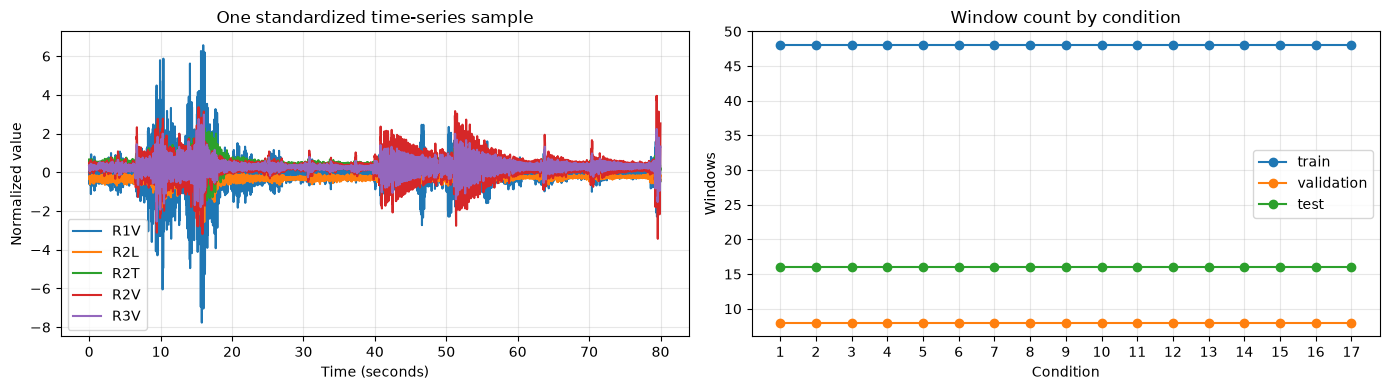

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
time_seconds = np.arange(WINDOW_SAMPLES) / 100.0
for channel_index, channel_name in enumerate(CHANNELS):
    axes[0].plot(time_seconds, X_train[0, channel_index], label=channel_name)
axes[0].set_title("One standardized time-series sample")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Normalized value")
axes[0].legend()
axes[0].grid(alpha=0.3)

for name, labels in (
    ("train", y_train),
    ("validation", y_validation),
    ("test", y_test),
):
    axes[1].plot(
        range(1, NUM_CLASSES + 1),
        np.bincount(labels, minlength=NUM_CLASSES),
        marker="o",
        label=name,
    )
axes[1].set_title("Window count by condition")
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("Windows")
axes[1].set_xticks(range(1, NUM_CLASSES + 1))
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Build the tsai classifier

Only train and validation are combined for TSClassifier. The predefined split indexes preserve their original roles. Test remains outside the learner until final evaluation.

In [7]:
X, y, tsai_splits = combine_split_data(
    [X_train, X_validation],
    [y_train, y_validation],
)

timestamp = datetime.now().strftime("%d-%m-%Y_%H-%M-%S")
ARTIFACT_DIR = ROOT / "artifacts" / "tsai" / f"{MEASUREMENT}_{MODEL_ARCH}_{timestamp}"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=False)

learner = TSClassifier(
    X,
    y,
    splits=tsai_splits,
    tfms=[None, TSClassification()],
    arch=MODEL_ARCH,
    metrics=accuracy,
    bs=BATCH_SIZE,
    path=ARTIFACT_DIR,
    model_dir="models",
    seed=SEED,
    verbose=True,
)
learner.summary()


arch: ResNet(c_in=5 c_out=17 arch_config={} kwargs={})


<div></div>

ResNet (Input shape: 64 x 5 x 8000)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 64 x 8000      
Conv1d                                    2240       True      
BatchNorm1d                               128        True      
ReLU                                                           
Conv1d                                    20480      True      
BatchNorm1d                               128        True      
ReLU                                                           
Conv1d                                    12288      True      
BatchNorm1d                               128        True      
Conv1d                                    320        True      
BatchNorm1d                               128        True      
Add                                                            
ReLU                                                           
____________________________________________________________________________
             

## Train

Validation is used during training. Test is not used by fit_one_cycle.

In [8]:
learner.fit_one_cycle(EPOCHS, LEARNING_RATE)

epoch,train_loss,valid_loss,accuracy,time
0,2.788265,2.816187,0.051471,01:18
1,2.642092,2.741656,0.132353,01:17
2,2.475934,2.709455,0.147059,01:24
3,2.273832,3.204030,0.066176,01:23
4,2.095595,3.074186,0.132353,01:16
5,1.908893,3.210553,0.066176,01:09
6,1.729506,3.069416,0.110294,01:11
7,1.586614,3.433466,0.125000,01:19
8,1.444493,3.311575,0.088235,01:19
9,1.309105,3.621744,0.139706,01:19


## Final test evaluation

,precision,recall,f1-score,support
01: undamaged_reference_1,0.000,0.000,0.000,16.000
02: pier_settlement_system_installation,0.000,0.000,0.000,16.000
03: pier_settlement_20mm,0.400,0.625,0.488,16.000
04: pier_settlement_40mm,0.000,0.000,0.000,16.000
05: pier_settlement_80mm,0.000,0.000,0.000,16.000
06: pier_settlement_95mm,0.200,0.188,0.194,16.000
07: foundation_tilt,0.714,0.312,0.435,16.000
08: undamaged_reference_3,0.125,0.062,0.083,16.000
09: concrete_spalling_12m2,0.000,0.000,0.000,16.000
10: concrete_spalling_24m2,0.357,0.312,0.333,16.000


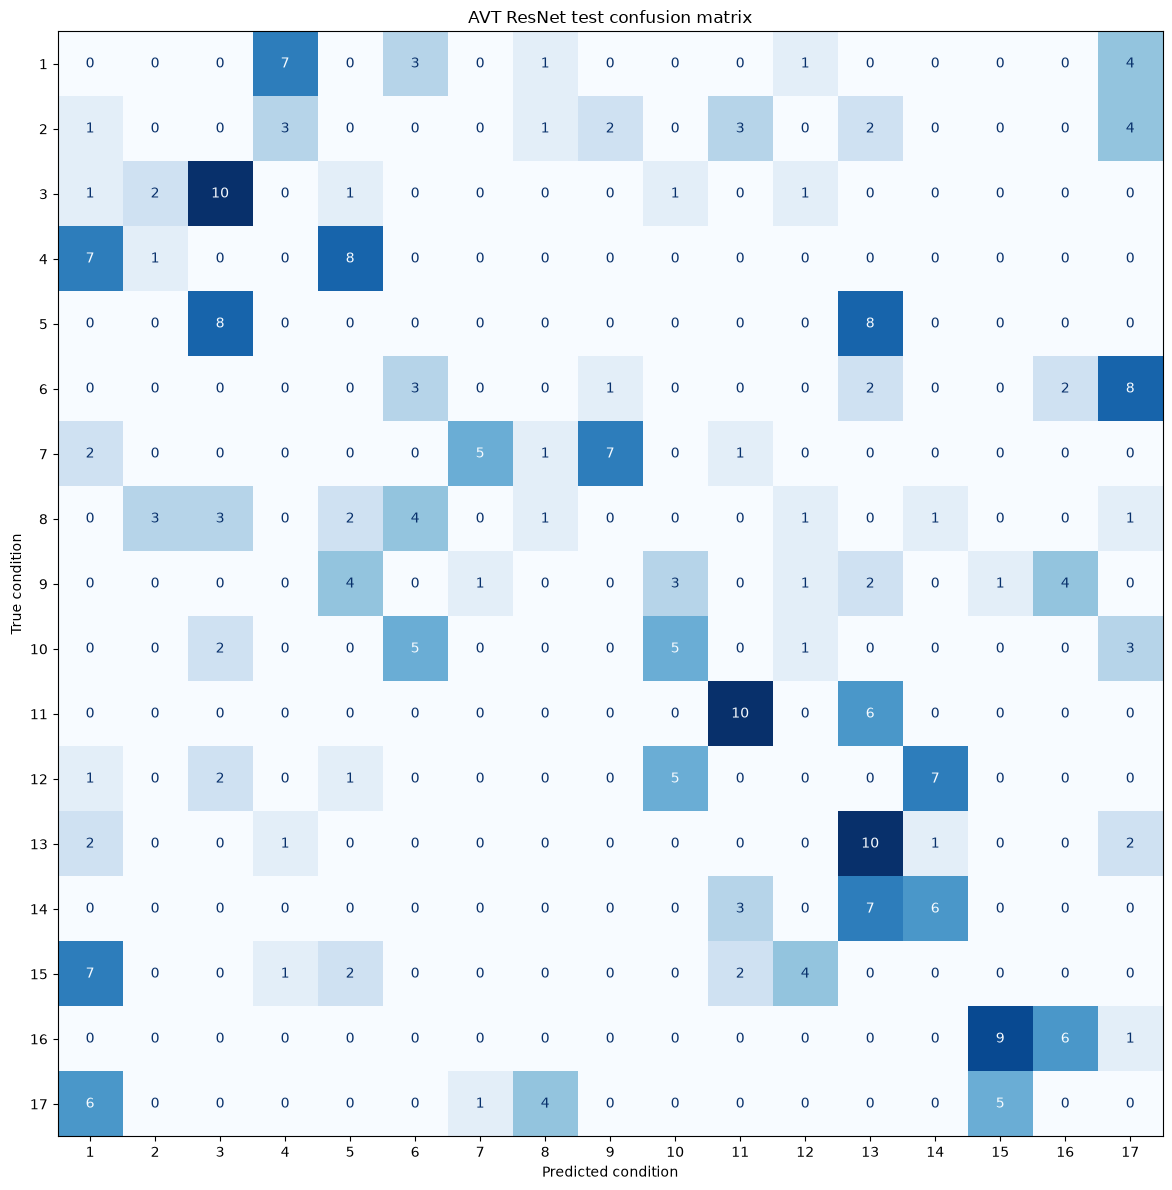

In [12]:
probabilities, targets, _ = learner.get_X_preds(
    X_test,
    y_test,
    bs=16,
    with_decoded=True,
)

# Convert probabilities to numeric class predictions.
if hasattr(probabilities, "detach"):
    probabilities = probabilities.detach().cpu().numpy()
else:
    probabilities = np.asarray(probabilities)
predictions = np.argmax(probabilities, axis=1).astype(np.int64)
y_test = np.asarray(y_test, dtype=np.int64).reshape(-1)

condition_names = [
    next(row["condition_name"] for row in MANIFEST if int(row["label"]) == label)
    for label in range(NUM_CLASSES)
]
report = classification_report(
    y_test,
    predictions,
    labels=np.arange(NUM_CLASSES),
    target_names=[f"{index + 1:02d}: {name}" for index, name in enumerate(condition_names)],
    output_dict=True,
    zero_division=0,
)
display(pd.DataFrame(report).T.round(3))

matrix = confusion_matrix(y_test, predictions, labels=np.arange(NUM_CLASSES))
fig, ax = plt.subplots(figsize=(12, 12))
ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=np.arange(1, NUM_CLASSES + 1),
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"{MEASUREMENT.upper()} {MODEL_ARCH} test confusion matrix")
ax.set_xlabel("Predicted condition")
ax.set_ylabel("True condition")
plt.tight_layout()
plt.show()

## Save model and experiment metadata

In [13]:
learner.export("z24_tsai_classifier.pkl")
pd.DataFrame(report).T.to_csv(ARTIFACT_DIR / "classification_report.csv")
np.savetxt(ARTIFACT_DIR / "confusion_matrix.csv", matrix, fmt="%d", delimiter=",")

experiment = {
    "measurement": MEASUREMENT,
    "model_architecture": MODEL_ARCH,
    "data_contract": "samples x variables x sequence_length",
    "train_shape": list(X_train.shape),
    "validation_shape": list(X_validation.shape),
    "test_shape": list(X_test.shape),
    "channels": CHANNELS,
    "sampling_rate_hz": 100,
    "window_samples": WINDOW_SAMPLES,
    "num_classes": NUM_CLASSES,
    "seed": SEED,
    "normalization_mean": channel_mean.tolist(),
    "normalization_std": channel_std.tolist(),
    "test_accuracy": float((predictions == y_test).mean()),
}
(ARTIFACT_DIR / "experiment.json").write_text(
    json.dumps(experiment, indent=2), encoding="utf-8"
)
print("Saved to:", ARTIFACT_DIR)

Saved to: C:\Users\phuotran\Data\research\shm\artifacts\tsai\avt_ResNet_20-09-2026_08-33-52


In [14]:
# Final accuracy summary
def tsai_accuracy(X, y):
    probabilities, _, _ = learner.get_X_preds(
        X, y, bs=16, with_decoded=True
    )
    if hasattr(probabilities, "detach"):
        probabilities = probabilities.detach().cpu().numpy()
    else:
        probabilities = np.asarray(probabilities)
    predictions = np.argmax(probabilities, axis=1)
    targets = np.asarray(y).reshape(-1)
    return float(np.mean(predictions == targets))

train_accuracy = tsai_accuracy(X_train, y_train)
validation_accuracy = tsai_accuracy(X_validation, y_validation)
test_accuracy = tsai_accuracy(X_test, y_test)

print(f"Training accuracy:   {train_accuracy:.2%}")
print(f"Validation accuracy: {validation_accuracy:.2%}")
print(f"Test accuracy:       {test_accuracy:.2%}")

Training accuracy:   95.83%
Validation accuracy: 6.62%
Test accuracy:       20.59%
